In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 4, "cos": 4}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


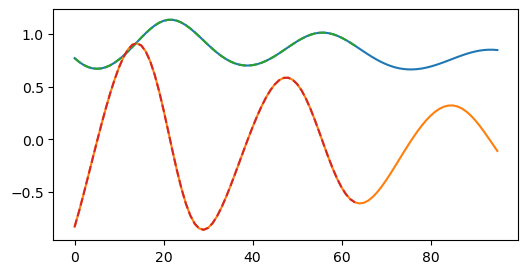

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.back_nsample + args.fore_nsample]
        back = replay[:, offset:offset + args.back_nsample]

        true, _ = dataset.normalizer.normalize(true)
        back, _ = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        #plt.plot(true_n[jdata, :, :2])
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.069024, valid=1.302434, test=1.188400
	validation loss decreased (inf -> 1.302434), saving model ...
	epoch 2 losses: train=1.077430, valid=1.293336, test=1.144079
	validation loss decreased (1.302434 -> 1.293336), saving model ...
	epoch 3 losses: train=1.032027, valid=1.294886, test=1.139696
	early stopping counter: 1 out of 100
	epoch 4 losses: train=1.025812, valid=1.293148, test=1.127180
	validation loss decreased (1.293336 -> 1.293148), saving model ...
	epoch 5 losses: train=1.012892, valid=1.289302, test=1.111328
	validation loss decreased (1.293148 -> 1.289302), saving model ...
	epoch 6 losses: train=0.996768, valid=1.286287, test=1.096788
	validation loss decreased (1.289302 -> 1.286287), saving model ...
	epoch 7 losses: train=0.981906, valid=1.284692, test=1.083399
	validation loss decreased (1.286287 -> 1.284692), saving model ...
	epoch 8 losses: train=0.967662, valid=1.284789, test=1.068583
	early stopping counter: 

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

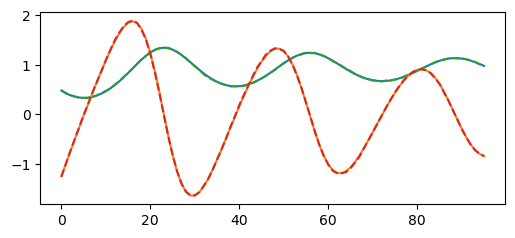

In [8]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

#print(tata.shape)

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.809221, valid=0.042844, test=1.027561
	validation loss decreased (inf -> 0.042844), saving model ...
	epoch 2 losses: train=0.776826, valid=0.040985, test=1.014504
	validation loss decreased (0.042844 -> 0.040985), saving model ...
	epoch 3 losses: train=0.766529, valid=0.038901, test=1.001672
	validation loss decreased (0.040985 -> 0.038901), saving model ...
	epoch 4 losses: train=0.756173, valid=0.037087, test=0.988950
	validation loss decreased (0.038901 -> 0.037087), saving model ...
	epoch 5 losses: train=0.746087, valid=0.035966, test=0.975878
	validation loss decreased (0.037087 -> 0.035966), saving model ...
	epoch 6 losses: train=0.736390, valid=0.035515, test=0.961803
	validation loss decreased (0.035966 -> 0.035515), saving model ...
	epoch 7 losses: train=0.726183, valid=0.035607, test=0.946736
	early stopping counter: 1 out of 100
	epoch 8 losses: train=0.715181, valid=0.036379, test=0.930612
	early stopping co

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

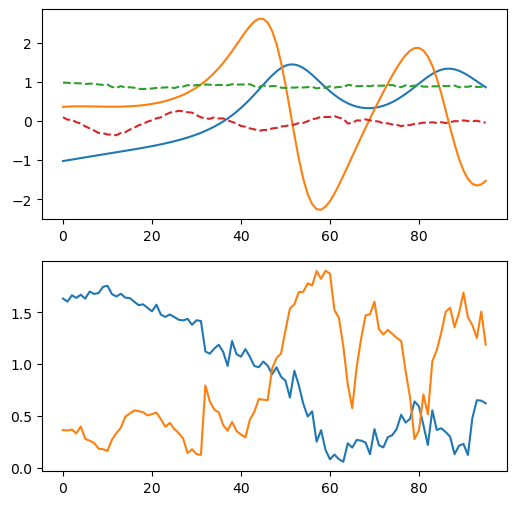

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.967589, valid=0.929413, test=0.964507
	validation loss decreased (inf -> 0.929413), saving model ...
	epoch 2 losses: train=0.928571, valid=0.914133, test=0.897710
	validation loss decreased (0.929413 -> 0.914133), saving model ...
	epoch 3 losses: train=0.856227, valid=0.896187, test=0.834260
	validation loss decreased (0.914133 -> 0.896187), saving model ...
	epoch 4 losses: train=0.836903, valid=0.693999, test=0.677200
	validation loss decreased (0.896187 -> 0.693999), saving model ...
	epoch 5 losses: train=0.718320, valid=0.596472, test=0.608312
	validation loss decreased (0.693999 -> 0.596472), saving model ...
	epoch 6 losses: train=0.645348, valid=0.541718, test=0.567810
	validation loss decreased (0.596472 -> 0.541718), saving model ...
	epoch 7 losses: train=0.638511, valid=0.495397, test=0.547675
	validation loss decreased (0.541718 -> 0.495397), saving model ...
	epoch 8 losses: train=0.530983, valid=0.455310, test=0.

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

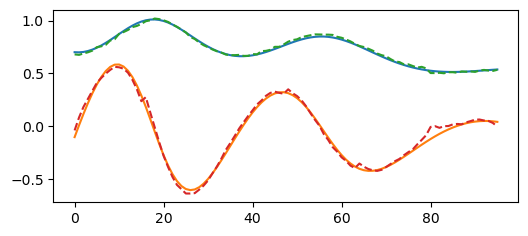

In [14]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.096299, valid=0.128116, test=0.043798
	validation loss decreased (inf -> 0.128116), saving model ...
	epoch 2 losses: train=0.064903, valid=0.123716, test=0.040029
	validation loss decreased (0.128116 -> 0.123716), saving model ...
	epoch 3 losses: train=0.060693, valid=0.122390, test=0.038522
	validation loss decreased (0.123716 -> 0.122390), saving model ...
	epoch 4 losses: train=0.058784, valid=0.120003, test=0.035911
	validation loss decreased (0.122390 -> 0.120003), saving model ...
	epoch 5 losses: train=0.054698, valid=0.117532, test=0.033680
	validation loss decreased (0.120003 -> 0.117532), saving model ...
	epoch 6 losses: train=0.052055, valid=0.115643, test=0.032226
	validation loss decreased (0.117532 -> 0.115643), saving model ...
	epoch 7 losses: train=0.050831, valid=0.114368, test=0.031304
	validation loss decreased (0.115643 -> 0.114368), saving model ...
	epoch 8 losses: train=0.048979, valid=0.113497, 

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

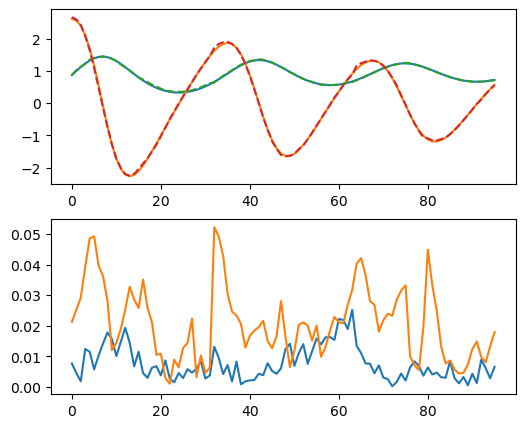

In [17]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

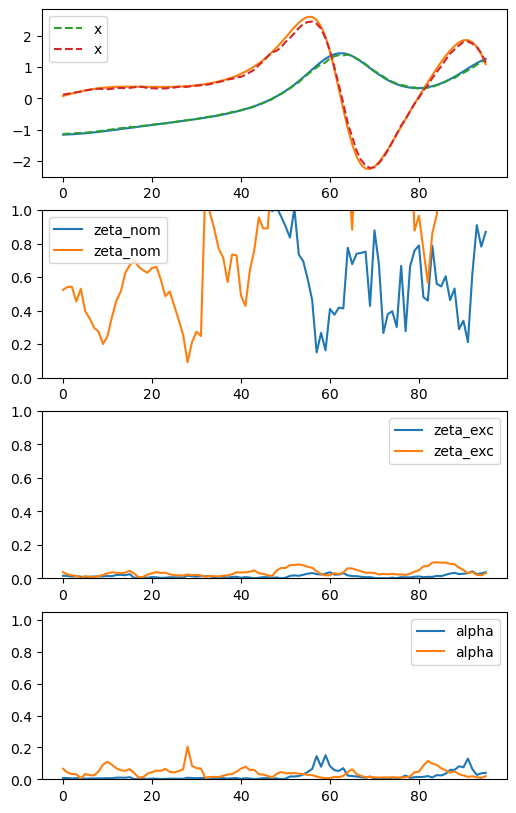

In [18]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break